# Weighted KNN

## Сегодня на практическом занятии:

1. Поработаем с 4 разными задачами (2 для классификации и 2 для регрессии)
2. Обучим модель Weighted KNN (взвешенный KNN) из sklearn
3. Получим предсказания моделью Weighted KNN (взвешенный KNN) вручную
4. Напишем свой способ подсчета весов для  Weighted KNN (взвешенный KNN)

## KNN для классификации

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [2]:
from sklearn.datasets import load_iris
from sklearn.datasets import fetch_olivetti_faces
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Возьмите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [5]:
# Ваш код здесь
X03 = X.iloc[:, [0, 3]]
X03.head()

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2


### Визуализируйте ваши данные на графике

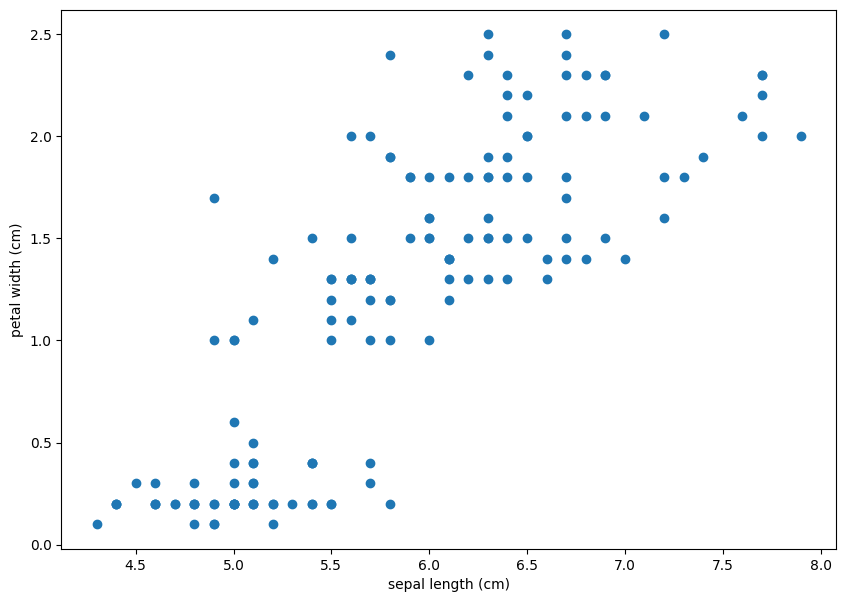

In [6]:
# Ваш код здесь
plt.figure(figsize=(10, 7))
plt.scatter(x=X03['sepal length (cm)'], y=X03['petal width (cm)'])
plt.xlabel('sepal length (cm)')
plt.ylabel('petal width (cm)')

plt.show()

### 1. KNN из sklearn

#### 1.1. Разбейте данные на обучение и тест

In [7]:
# Ваш код здесь
X03_train, X03_test, y_train, y_test = train_test_split(X03, y, random_state=10, test_size=10)
X03_train.shape, X03_test.shape

((140, 2), (10, 2))

#### 1.2. Обучите модель KNN на 50 соседях

In [8]:
# Ваш код здесь
n_neighbors = 50

knn_classifer = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_classifer.fit(X03_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 1.3. Проверьте качество работы модели

Для регрессии берем R^2, для классификации - accuracy


In [9]:
# Ваш код здесь
pred_knn_classifer = knn_classifer.predict(X03_test)
display(pred_knn_classifer, y_test)

accuracy = accuracy_score(y_test, pred_knn_classifer)
print(f"accuracy score: {accuracy}")

array([1, 2, 0, 1, 0, 0, 1, 1, 0, 1])

array([1, 2, 0, 1, 0, 1, 1, 1, 0, 1])

accuracy score: 0.9


#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [10]:
# Ваш код здесь
X03_train_numpy = X03_train.to_numpy()
X03_test_numpy = X03_test.to_numpy()

idx = 7
test_dot = X03_test_numpy[idx]
distance_list = []
for i, train_dot in enumerate(X03_train_numpy):  # 1
    distance_list.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2),  # 2
        'class': y_train[i]
    })
distances = pd.DataFrame(distance_list)

#### 1.5. Выберите топ  k  соседей


In [11]:
# Ваш код здесь
top_k = distances.sort_values('dst').head(n_neighbors)
top_k

,train_idx,dst,class
67,67,0.100000,1
58,58,0.200000,1
111,111,0.200000,1
121,121,0.200000,1
16,16,0.223607,1
116,116,0.223607,1
42,42,0.300000,1
73,73,0.316228,1
69,69,0.316228,1
87,87,0.316228,1


#### 1.6. Выведите финальное предсказание для этого объекта

In [12]:
pred_class = int(top_k['class'].value_counts().index[0])
print(f"предсказание для i={idx}: { pred_class }")

предсказание для i=7: 1


#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [13]:
# Ваш код здесь
print(f"true: {y_test[idx]}")
print(f"scylearn: {knn_classifer.predict([test_dot])[0]}")
print(f"my: {pred_class}")

true: 1
scylearn: 1
my: 1


d:\J\ed\ML\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

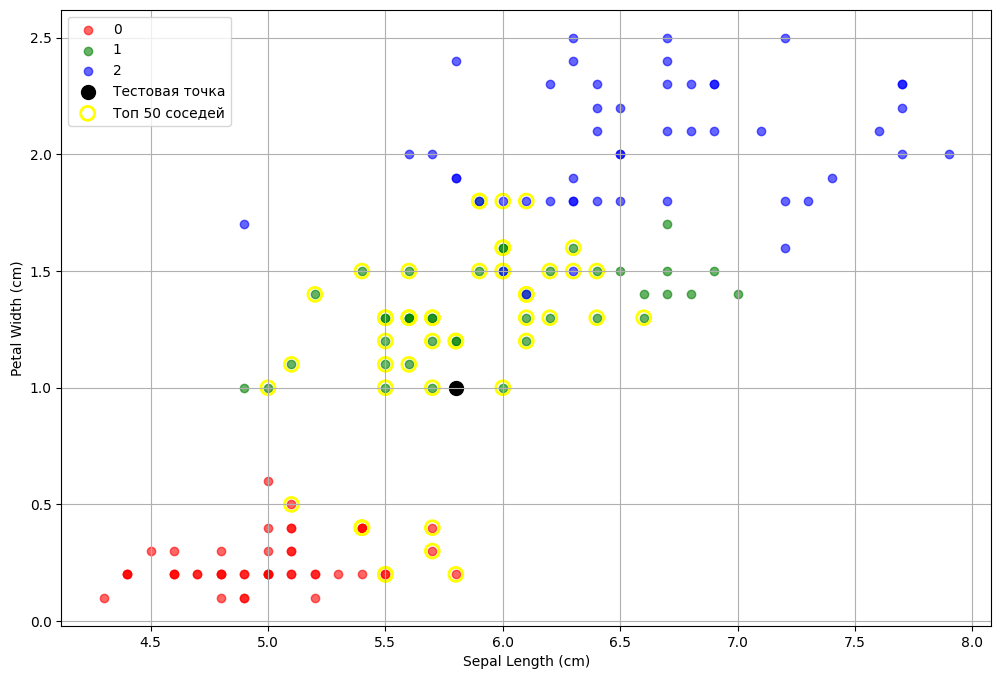

In [14]:
neighbors_indices = top_k['train_idx'].values
k = n_neighbors

colors = {0:'red', 1:'green', 2:'blue'}
class_names = {0:'0', 1:'1', 2:'2'}

plt.figure(figsize=(12, 8))

for cls in [0, 1, 2]:
    mask = (y_train == cls)
    plt.scatter(X03_train_numpy[mask, 0], X03_train_numpy[mask, 1], 
                c=colors[cls], label=class_names[cls], alpha=0.6)

plt.scatter(test_dot[0], test_dot[1], 
            c='black', s=100, label='Тестовая точка')

neighbors_points = X03_train_numpy[neighbors_indices]
plt.scatter(neighbors_points[:,0], neighbors_points[:,1],
            s=100, facecolors='none', edgecolors='yellow', 
            linewidths=2, label=f'Топ {k} соседей')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()

### 2. Weighted KNN

#### 2.1. Обучите модель взвешенный KNN по дистанции

In [15]:
knnw = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
knnw.fit(X03_train, y_train)


KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 2.2. Проверьте качество работы модели


In [16]:
# Ваш код здесь

pred_train = knnw.predict(X03_train)
pred_test = knnw.predict(X03_test)

print(f'Train acc {accuracy_score(y_train, pred_train)}')
print(f'Test acc {accuracy_score(y_test, pred_test)}')

Train acc 0.9785714285714285
Test acc 0.9


#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [17]:
# Ваш код здесь
idx = 7
test_dot = X03_test_numpy[idx]
distance_list = []
for i, train_dot in enumerate(X03_train_numpy):  # 1
    distance_list.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2),  # 2
        'class': y_train[i]
    })
distances = pd.DataFrame(distance_list)

#### 2.4. Выберите топ  k  соседей


In [18]:
# Ваш код здесь
top_k_w = distances.sort_values('dst').head(n_neighbors)
top_k_w

,train_idx,dst,class
67,67,0.100000,1
58,58,0.200000,1
111,111,0.200000,1
121,121,0.200000,1
16,16,0.223607,1
116,116,0.223607,1
42,42,0.300000,1
73,73,0.316228,1
69,69,0.316228,1
87,87,0.316228,1


#### 2.5. Рассчитайте вес для каждого соседа

In [19]:
# Ваш код здесь. Чтобы не ловить warning о делении на 0 можно сделать так: distances['dst'] + 1e-4
top_k_w['weight'] = 1 / (top_k_w['dst'] + 1e-4)
top_k_neighbors_idxs = top_k_w.sort_values('weight', ascending=False).head(n_neighbors)
top_k_neighbors_idxs.head()

,train_idx,dst,class,weight
67,67,0.100000,1,9.990010
58,58,0.200000,1,4.997501
111,111,0.200000,1,4.997501
121,121,0.200000,1,4.997501
16,16,0.223607,1,4.470137


#### 2.6. Выведите финальное предсказание для этого объекта

In [20]:
# Ваш код здесь
pred_knnw = top_k_neighbors_idxs.groupby('class', as_index=False).agg(sum_weights=('weight', 'sum')).sort_values('sum_weights', ascending=False)
pred_knnw

,class,sum_weights
1,1,94.141648
0,0,11.970142
2,2,8.893221


#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [21]:
pred_class_knnw = int(pred_knnw['class'].index[0])
print(f"True {y_test[idx]}")
print(f"Sklearn {knnw.predict([test_dot])[0]}")
print(f"My {pred_class_knnw}")

True 1
Sklearn 1
My 1


d:\J\ed\ML\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

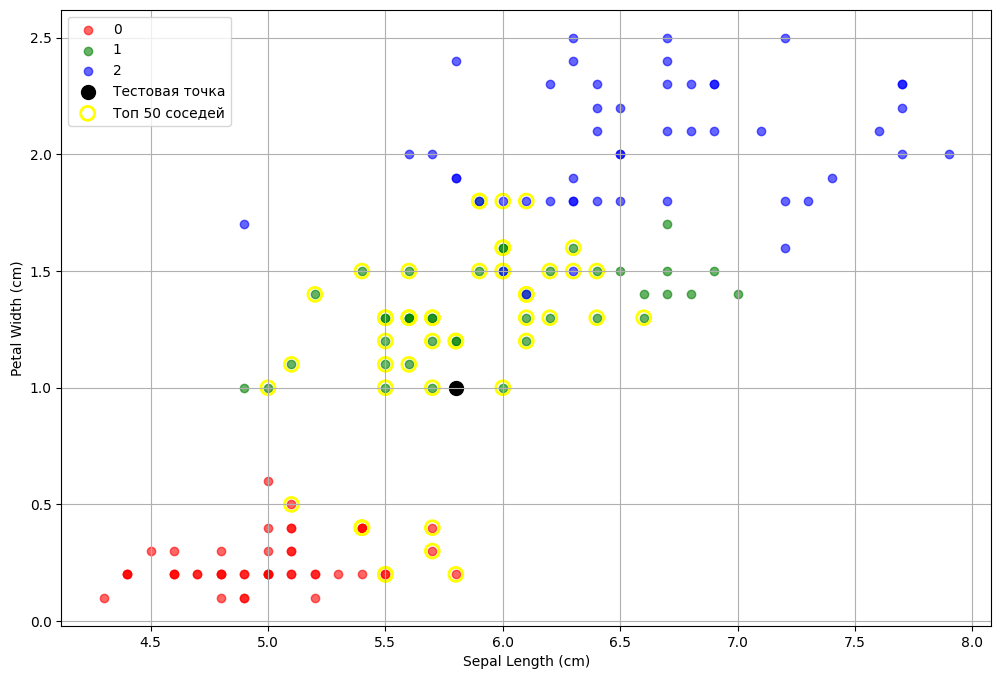

In [22]:
# Ваш код здесь
neighbors_indices = top_k_w['train_idx'].values
k = n_neighbors

colors = {0:'red', 1:'green', 2:'blue'}
class_names = {0:'0', 1:'1', 2:'2'}

plt.figure(figsize=(12, 8))

for cls in [0, 1, 2]:
    mask = (y_train == cls)
    plt.scatter(X03_train_numpy[mask, 0], X03_train_numpy[mask, 1], 
                c=colors[cls], label=class_names[cls], alpha=0.6)

plt.scatter(test_dot[0], test_dot[1], 
            c='black', s=100, label='Тестовая точка')

neighbors_points = X03_train_numpy[neighbors_indices]
plt.scatter(neighbors_points[:,0], neighbors_points[:,1],
            s=100, facecolors='none', edgecolors='yellow', 
            linewidths=2, label=f'Топ {k} соседей')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Еще одна задача классификации

### Получение данных

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

In [23]:
data = fetch_olivetti_faces(shuffle=True, random_state=9)

X = pd.DataFrame(data['data'])
y = data['target']

X.head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.723140,0.710744,0.714876,0.731405,0.735537,0.752066,0.772727,0.793388,0.814050,0.834711,...,0.793388,0.904959,0.549587,0.409091,0.491736,0.487603,0.471074,0.483471,0.475207,0.475207
1,0.289256,0.157025,0.148760,0.190083,0.169421,0.194215,0.404959,0.607438,0.669421,0.677686,...,0.438017,0.400826,0.421488,0.429752,0.433884,0.425620,0.438017,0.438017,0.210744,0.206612
2,0.586777,0.595041,0.681818,0.694215,0.714876,0.698347,0.714876,0.727273,0.743802,0.739669,...,0.495868,0.380165,0.400826,0.330579,0.148760,0.119835,0.123967,0.115702,0.119835,0.107438
3,0.235537,0.351240,0.479339,0.545455,0.566116,0.566116,0.595041,0.607438,0.619835,0.623967,...,0.169421,0.198347,0.202479,0.214876,0.202479,0.214876,0.214876,0.214876,0.210744,0.206612
4,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893


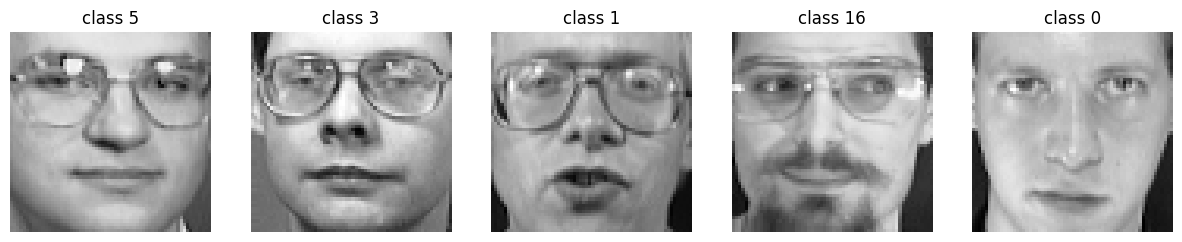

In [24]:
fig, ax = plt.subplots(1, 5, figsize=(15, 8))

for i in range(0, 5):
    ax[i].imshow(X.iloc[i].values.reshape((64, 64)), cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'class {y[i]}')

plt.show()

In [25]:
y

array([ 5,  3,  1, 16,  0,  1, 12,  9, 26, 37, 20,  5, 10, 27, 10, 34, 13,
       26, 17, 31,  9,  7, 31, 37, 31, 35, 18, 29, 29,  4, 21, 20, 23,  7,
        9, 18, 22,  2,  1, 39, 36,  8, 34, 32,  3, 20,  3,  9, 37, 32, 34,
       15,  9, 16, 36, 16, 13,  7, 29,  6, 13,  4, 16,  0,  8,  1, 25,  3,
       18, 29,  8, 35,  2, 25, 21, 31, 35, 23, 30, 28,  4, 10, 11, 27, 29,
       39,  5, 12, 29, 26, 15,  2, 39,  6, 30, 37, 25, 32, 35, 24, 15, 24,
        2, 19, 22,  0, 38,  5, 22, 28,  6, 38,  6,  3, 33, 12, 36,  8, 27,
       19, 25, 36, 10, 37,  9, 33, 10, 28, 32, 34, 17, 23, 19, 24, 27,  3,
       39, 30,  3,  7,  3, 30, 12, 21, 17, 14, 35, 21, 19,  5, 32, 16, 19,
        8, 33, 14, 17, 15, 22, 38, 15, 18,  7, 14, 28, 39, 23, 36, 28, 10,
       39, 36, 37, 10, 34, 25, 18, 13, 19, 33, 33, 13, 26,  9, 13, 34, 24,
        0, 30, 23,  2, 22,  9, 11,  7, 35, 19, 26, 32, 11,  7,  7,  0,  4,
        0,  2,  0, 26, 21, 14,  4, 32,  1, 23, 16,  0,  7, 14, 16, 15, 39,
       17, 33, 30, 37, 17

### 3.1. KNN из sklearn

#### 3.1.1. Разбейте данные на обучение и тест

In [26]:
# Ваш код здесь
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=30)
X_train.shape, X_test.shape

((370, 4096), (30, 4096))

#### 3.1.2. Обучите модель KNN на 50 соседях

In [27]:
# Ваш код здесь
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50)

#### 3.1.3. Проверьте качество работы модели


In [28]:
# Ваш код здесь
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.27


### 3.2. Weighted KNN

#### 3.2.1. Обучите модель взвешенный KNN по дистанции

In [29]:
# Ваш код здесь
knnw = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')
knnw.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50, weights='distance')

#### 3.2.2. Проверьте качество работы модели


In [30]:
# Ваш код здесь
y_pred = knnw.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.47


### 3.3. Custom Weighted KNN

#### 3.3.1. Напишите свою функцию подсчета весов по дистанции

(Можете выбрать любой подход)

In [31]:
# Ваш код здесь. реализуйте функцию custom_distance.
def custom_distance(distances):
    return 1 / (distances**2 + 1e-4)

#### 3.3.2. Обучите модель взвешенный KNN по написанной функции выше

In [32]:
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=custom_distance)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=50,
                     weights=<function custom_distance at 0x00000251894770A0>)

#### 3.3.3. Проверьте качество работы модели


In [33]:
# Ваш код здесь
y_pred = knnw.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.47


## KNN для регрессии

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [34]:
data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [35]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

### Возьмите только признак MedInc и 1000 первых строк

In [36]:
# Ваш код здесь
X = X[["MedInc"]].iloc[:1000]
y = y[:1000]

### Отрисуйте данные на графике

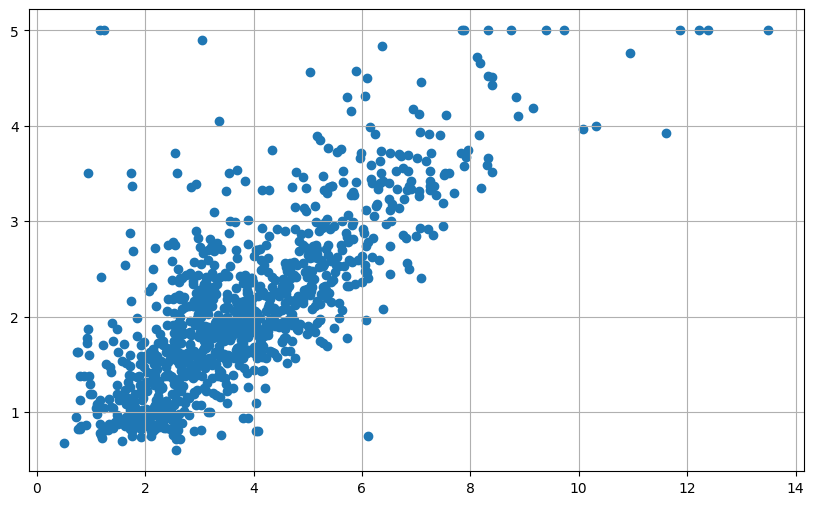

In [37]:
# Ваш код здесь
plt.figure(figsize=(10, 6))
plt.scatter(X, y)
plt.grid(True)
plt.show()

### 4. KNN из sklearn

#### 4.1. Разбейте данные на обучение и тест

In [38]:
# Ваш код здесь
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=50)
X_train.shape, X_test.shape

((950, 1), (50, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [39]:
# Ваш код здесь
n_neighbors = 100
knn = KNeighborsRegressor(n_neighbors=n_neighbors)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100)

#### 4.3. Проверьте качество работы модели




In [40]:
# Ваш код здесь
y_pred_knn = knn.predict(X_test)
r2 = r2_score(y_test, y_pred_knn)
r2

0.7181786573255746

#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [41]:
# Ваш код здесь
idx = 7
X_test = X_test.to_numpy()
X_train = X_train.to_numpy()
test_dot = X_test[idx]

distance_list = []
for i, train_dot in enumerate(X_train):
    distance_list.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2),
        'y': y_train[i]
    })
distances = pd.DataFrame(distance_list)
distances

,train_idx,dst,y
0,0,2.3659,1.055
1,1,1.5801,0.735
2,2,2.2826,0.912
3,3,0.9395,2.455
4,4,0.8755,1.607
...,...,...,...
945,945,3.3727,0.818
946,946,0.9968,2.102
947,947,4.9792,4.188
948,948,1.2831,3.373


#### 4.5. Выберите топ  k  соседей


In [42]:
# Ваш код здесь
top_k = distances.sort_values(by='dst').head(n_neighbors)
top_k

,train_idx,dst,y
556,556,0.0011,1.440
352,352,0.0020,1.870
466,466,0.0072,2.258
246,246,0.0087,1.582
720,720,0.0142,2.932
...,...,...,...
230,230,0.2717,1.917
261,261,0.2739,2.757
313,313,0.2781,3.011
298,298,0.2810,2.095


#### 4.6. Выведите финальное предсказание для этого объекта

In [43]:
# Ваш код здесь
y_pred_knn = top_k['y'].sum() / top_k['y'].count() 
y_pred_knn

np.float64(2.07434)

#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [44]:
# Ваш код здесь
print(f"True {y_test[idx]}")
print(f"Sklearn {knn.predict([test_dot])[0]}")
print(f"My {y_pred_knn}")

True 1.696
Sklearn 2.07434
My 2.07434


d:\J\ed\ML\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

d:\J\ed\ML\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


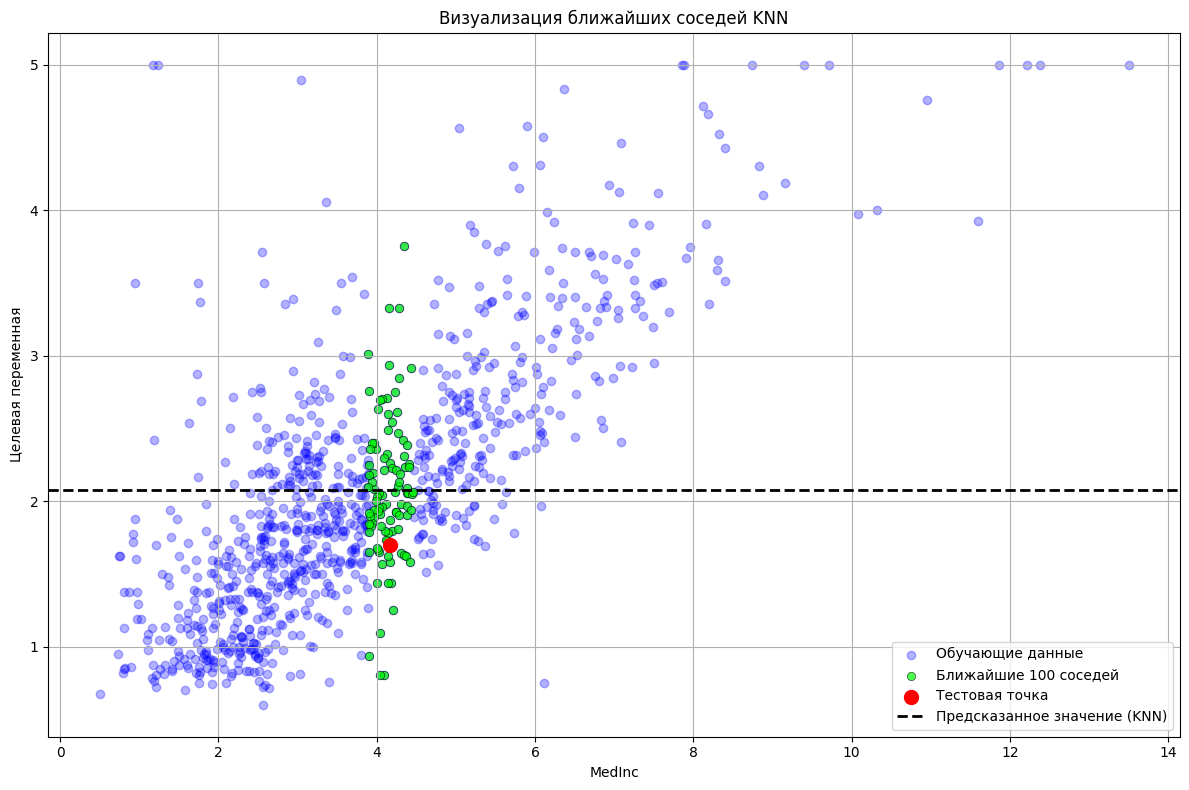

In [45]:
# Ваш код здесь
train_medinc = X_train.squeeze()
train_target = y_train

test_medinc = test_dot[0]
test_target = y_test[idx]

neighbors_indices = top_k['train_idx'].values
neighbors_medinc = X_train[neighbors_indices].squeeze()
neighbors_target = y_train[neighbors_indices]

plt.figure(figsize=(12, 8))

plt.scatter(train_medinc, train_target, 
            c='blue', alpha=0.3, label='Обучающие данные')

plt.scatter(neighbors_medinc, neighbors_target, 
            c='lime', edgecolor='black', lw=0.5, alpha=0.7,
            label=f'Ближайшие {n_neighbors} соседей')

plt.scatter(test_medinc, test_target, 
            c='red', s=100, label='Тестовая точка')

plt.axhline(y=knn.predict([test_dot])[0], color='black', linestyle='--', 
            lw=2, label='Предсказанное значение (KNN)')

plt.xlabel('MedInc')
plt.ylabel('Целевая переменная')
plt.title('Визуализация ближайших соседей KNN')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### 5. Weighted KNN

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [46]:
# Ваш код здесь
knnw = KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance")
knnw.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=100, weights='distance')

#### 5.2. Проверьте качество работы модели


In [47]:
# Ваш код здесь
y_pred_knnw = knnw.predict(X_test)
r2 = r2_score(y_test, y_pred_knnw)
r2

0.7327267088647259

#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [48]:
# Ваш код здесь
idx = 7
test_dot = X_test[idx]

distance_list = []
for i, train_dot in enumerate(X_train):  # 1
    distance_list.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2),  # 2
        'y': y_train[i]
    })
distances = pd.DataFrame(distance_list)
distances

,train_idx,dst,y
0,0,2.3659,1.055
1,1,1.5801,0.735
2,2,2.2826,0.912
3,3,0.9395,2.455
4,4,0.8755,1.607
...,...,...,...
945,945,3.3727,0.818
946,946,0.9968,2.102
947,947,4.9792,4.188
948,948,1.2831,3.373


#### 5.4. Выберите топ  k  соседей


In [49]:
# Ваш код здесь
top_k = distances.sort_values(by='dst').head(n_neighbors)
top_k

,train_idx,dst,y
556,556,0.0011,1.440
352,352,0.0020,1.870
466,466,0.0072,2.258
246,246,0.0087,1.582
720,720,0.0142,2.932
...,...,...,...
230,230,0.2717,1.917
261,261,0.2739,2.757
313,313,0.2781,3.011
298,298,0.2810,2.095


#### 5.5. Рассчитайте вес для каждого соседа

In [50]:
# Ваш код здесь
top_k['weight'] = 1 / (top_k['dst'] + 1e-4)
top_k = top_k.sort_values('dst').head(n_neighbors)
top_k

,train_idx,dst,y,weight
556,556,0.0011,1.440,833.333333
352,352,0.0020,1.870,476.190476
466,466,0.0072,2.258,136.986301
246,246,0.0087,1.582,113.636364
720,720,0.0142,2.932,69.930070
...,...,...,...,...
230,230,0.2717,1.917,3.679176
261,261,0.2739,2.757,3.649635
313,313,0.2781,3.011,3.594536
298,298,0.2810,2.095,3.557453


#### 5.6. Выведите финальное предсказание для этого объекта

In [51]:
# Ваш код здесь
y_pred_knnw = float((top_k['y'] * top_k['weight']).sum() / top_k['weight'].sum())
y_pred_knnw

1.8804528273279932

#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [52]:
# Ваш код здесь
print(f"True {y_test[idx]}")
print(f"Sklearn {knnw.predict([test_dot])[0]}")
print(f"My {y_pred_knnw}")

True 1.696
Sklearn 1.8691068901783976
My 1.8804528273279932


#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

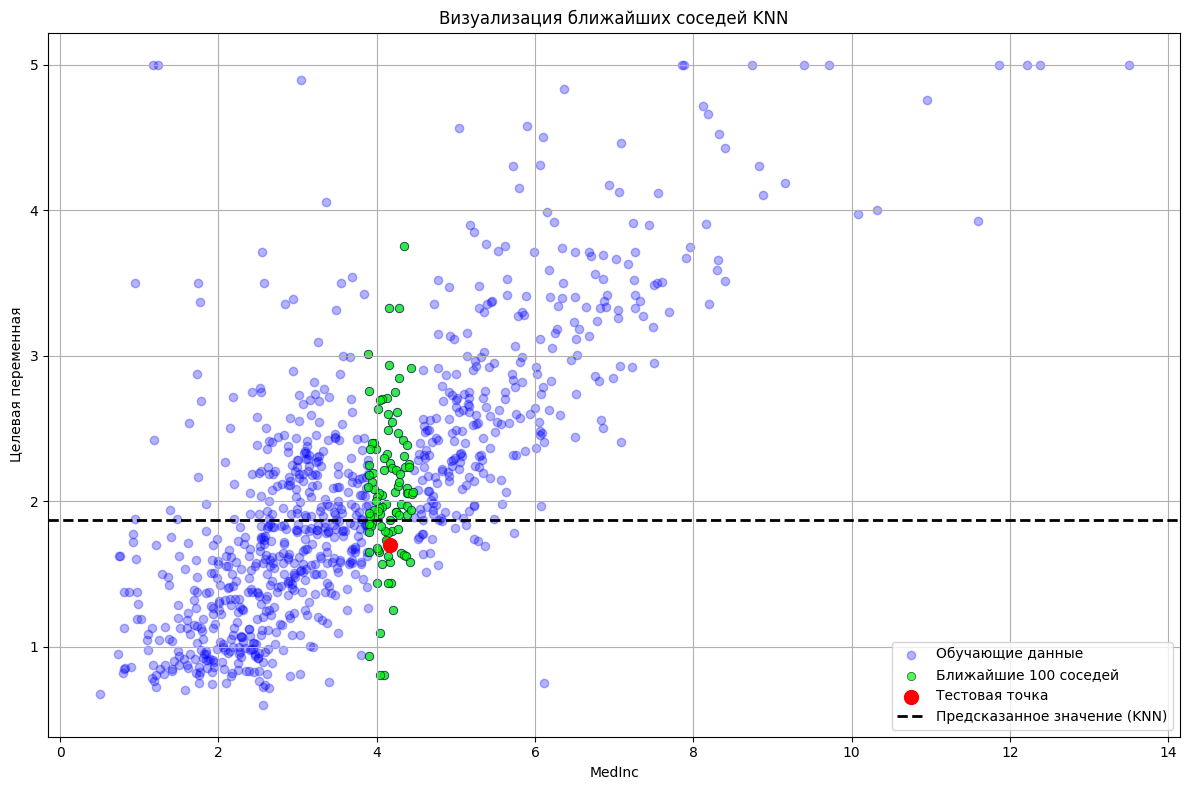

In [53]:
# Ваш код здесь
train_medinc = X_train.squeeze()
train_target = y_train

test_medinc = test_dot[0]
test_target = y_test[idx]

neighbors_indices = top_k['train_idx'].values
neighbors_medinc = X_train[neighbors_indices].squeeze()
neighbors_target = y_train[neighbors_indices]

plt.figure(figsize=(12, 8))

plt.scatter(train_medinc, train_target, 
            c='blue', alpha=0.3, label='Обучающие данные')

plt.scatter(neighbors_medinc, neighbors_target, 
            c='lime', edgecolor='black', lw=0.5, alpha=0.7,
            label=f'Ближайшие {n_neighbors} соседей')

plt.scatter(test_medinc, test_target, 
            c='red', s=100, label='Тестовая точка')

plt.axhline(y=knnw.predict([test_dot])[0], color='black', linestyle='--', 
            lw=2, label='Предсказанное значение (KNN)')

plt.xlabel('MedInc')
plt.ylabel('Целевая переменная')
plt.title('Визуализация ближайших соседей KNN')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Резюме

Сегодня на практическом занятии:
1. Поработали с 4 разными задачами (2 для классификации и 1 для регрессии)
2. Обучили модель Weighted KNN (взвешенный KNN) из sklearn
3. Получили предсказания моделью Weighted KNN (взвешенный KNN) вручную
4. Написали свой способ подсчета весов для  Weighted KNN (взвешенный KNN)